# Regression Discontinuity: The Minimum Legal Drinking Age and Alcohol Consumption

**Question:** Does gaining legal access to alcohol at age 21 actually change drinking behavior?

**Data:** National Health Interview Survey (NHIS) Sample Adult Files. Each row is one individual,
with demographics and whether they reported drinking alcohol in the past month. The running
variable is age measured in **days**, centered at the 21st birthday (`days_21` = 0 on the day
someone turns 21).

**Design:** A sharp regression discontinuity (RD). Nobody can manipulate their birthdate, so
whether someone is just above or just below the cutoff is effectively random, even though age
itself is obviously not randomly assigned across the whole population. Comparing people a few
days apart, right at the cutoff, isolates the effect of *legal access* from the effect of simply
being older.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:.3f}')

df = pd.read_stata('../data/nhis_drinking.dta')
print(f"Full data: {df.shape[0]:,} rows")

# Restrict to a symmetric 2-year bandwidth around the cutoff, as in the original design
df = df[(df['age_yrs'] >= 19) & (df['age_yrs'] <= 22)].copy()
print(f"Restricted to ages 19-22: {df.shape[0]:,} rows")

df['over21'] = (df['days_21'] >= 0).astype(int)
df['days_21_sq'] = df['days_21'] ** 2
df['days_21_cu'] = df['days_21'] ** 3

Full data: 61,784 rows
Restricted to ages 19-22: 18,811 rows


## Table 1: RD estimates of the effect on drinking

Specification allows the slope in age to differ on each side of the cutoff (interacted polynomial terms). We check linear, quadratic, and cubic specifications to see whether the result is sensitive to functional form.

In [2]:
specs = {
    'Linear': 'drinks_alcohol ~ over21 + days_21 + over21:days_21',
    'Quadratic': 'drinks_alcohol ~ over21 + days_21 + days_21_sq + over21:days_21 + over21:days_21_sq',
    'Cubic': 'drinks_alcohol ~ over21 + days_21 + days_21_sq + days_21_cu + over21:days_21 + over21:days_21_sq + over21:days_21_cu',
}

results = {name: smf.ols(spec, data=df).fit(cov_type='HC1') for name, spec in specs.items()}

table1 = pd.DataFrame({
    name: {
        'Effect of Turning 21 (pp)': m.params['over21'] * 100,
        'Std. Error': m.bse['over21'] * 100,
        'P-value': m.pvalues['over21'],
        'N': int(m.nobs),
    }
    for name, m in results.items()
}).T
table1

,Effect of Turning 21 (pp),Std. Error,P-value,N
Linear,8.449,1.421,0.000,18811.000
Quadratic,9.263,2.149,0.000,18811.000
Cubic,8.264,2.902,0.004,18811.000


The estimated jump in drinking is **8-9 percentage points** and statistically significant across all three functional forms. The consistency across linear, quadratic, and cubic specs is reassuring, it means the result isn't an artifact of a particular choice of polynomial.

## Table 2: Balance test on covariates at the cutoff

If the design is valid, characteristics that shouldn't be affected by legal drinking access (gender, race, employment, marital status) should **not** jump at the cutoff. This checks for sorting or other confounds coinciding with turning 21.

In [3]:
balance_vars = ['male', 'uninsured', 'hs_diploma', 'hispanic', 'white', 'black', 'employed', 'married']

quad_spec = 'over21 + days_21 + days_21_sq + over21:days_21 + over21:days_21_sq'
rows = []
for var in balance_vars:
    m = smf.ols(f'{var} ~ {quad_spec}', data=df).fit(cov_type='HC1')
    rows.append({
        'Variable': var,
        'Jump at Cutoff': m.params['over21'],
        'Std. Error': m.bse['over21'],
        'P-value': m.pvalues['over21'],
    })

table2 = pd.DataFrame(rows).set_index('Variable')
table2

,Jump at Cutoff,Std. Error,P-value
Variable,,,
male,0.021,0.022,0.328
uninsured,-0.001,0.020,0.945
hs_diploma,0.033,0.017,0.055
hispanic,-0.001,0.019,0.945
white,0.012,0.022,0.566
black,-0.026,0.016,0.091
employed,0.027,0.021,0.194
married,-0.024,0.015,0.108


Most covariates show small, statistically insignificant jumps at the cutoff. This supports the identifying assumption: people just below and just above age 21 are comparable on observables, so the drinking discontinuity is plausibly attributable to legal access rather than some other characteristic that happens to change at 21.

## Figure: binned scatter plot with fitted RD lines

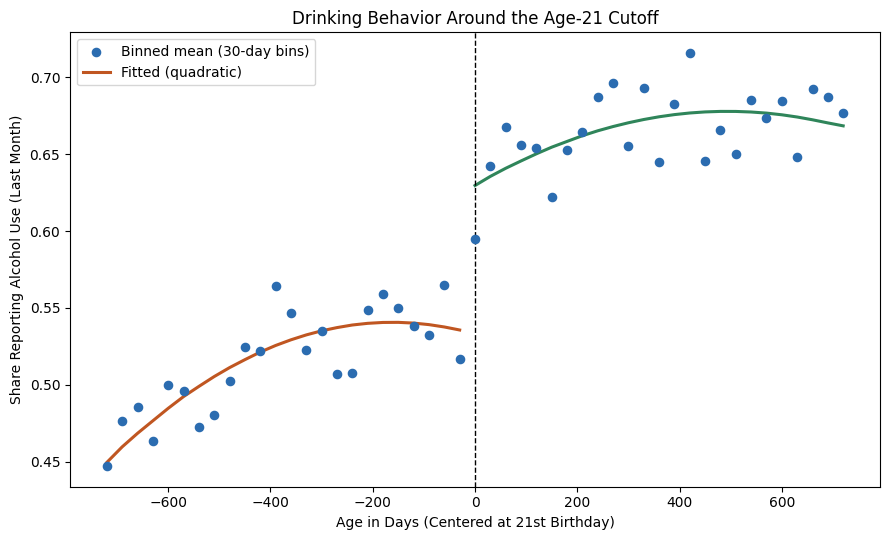

In [4]:
model_quad = results['Quadratic']
df['yhat'] = model_quad.predict(df)

df['bin_30'] = (np.floor(df['days_21'] / 30) * 30).astype(int)
binned = df.groupby('bin_30').agg(drink_rate=('drinks_alcohol', 'mean'),
                                    yhat_rate=('yhat', 'mean')).reset_index()
binned = binned[(binned['bin_30'] >= -730) & (binned['bin_30'] <= 730)]

left = binned[binned['bin_30'] < 0]
right = binned[binned['bin_30'] >= 0]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(binned['bin_30'], binned['drink_rate'], color='#2b6cb0', s=35, zorder=3, label='Binned mean (30-day bins)')
ax.plot(left['bin_30'], left['yhat_rate'], color='#c05621', linewidth=2.2, label='Fitted (quadratic)')
ax.plot(right['bin_30'], right['yhat_rate'], color='#2f855a', linewidth=2.2)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Age in Days (Centered at 21st Birthday)')
ax.set_ylabel('Share Reporting Alcohol Use (Last Month)')
ax.set_title('Drinking Behavior Around the Age-21 Cutoff')
ax.legend()
plt.tight_layout()
plt.savefig('rdd_figure.png', dpi=150)
plt.show()

## Takeaway

There's a clear, visible jump in reported drinking right at the 21st birthday, consistent in size
with the regression estimates (roughly 8-9 percentage points). The gradual upward trend on both
sides of the cutoff reflects the fact that drinking rates naturally rise with age throughout the
early twenties, the discontinuity isolates the piece of that increase that happens *exactly* at
the point of legal access, not the general age trend. Combined with the balance test showing no
comparable jump in unrelated characteristics, this is good evidence that legal access to alcohol
has a real, immediate behavioral effect, distinct from just getting older.